<a href="https://colab.research.google.com/github/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento/blob/main/MVP_Sprint_2_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Barbosa Leite Silva

**Matrícula:** 4052025002093

**Dataset:** [Marketing bancário](https://archive.ics.uci.edu/dataset/222/bank+marketing)

# Descrição do Problema

Os dados referem-se a campanhas de marketing direto (chamadas telefônicas) de uma instituição bancária portuguesa. O objetivo da classificação é prever se o cliente irá se inscrever em um depósito a prazo (variável result).

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?
2. Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?
3. Ligar mais vezes para um cliente diminui a chance dele contratar?
4. Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características, (como idade, número de ligações, dias entre as ligações, ocupação e nível de escolaridade), o objetivo é prever qual o resultado final do contato (yes/no ).

## Seleção de Dados

O dataset Bank Marketing é um dataset disponível no UCI Machine Learning Repository. Os dados referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing baseavam-se em chamadas telefónicas. Frequentemente, era necessário mais do que um contacto com o mesmo cliente para apurar se o produto (depósito a prazo bancário) seria contratado ("sim") ou não ("não"). O dataset é composto por 45211 instâncias e 17 colunas.

## Atributos do Dataset

O dataset Bank Marketing contém 41188 amostras, cada uma com 17 atributos (16 features e 1 target):

| Variável | Descrição | Tipo | Categorias |
|---       | ---       | ---  | ---        |
| **age**  | idade     | numérica | N/A    |
| **job**  | ocupação  | categórica | admin., blue-collar, entrepneur housemaid, management, retired, self-employed, services, student, <br>technician, unemployed, unknown |
| **marital** | situação conjugal | categórica | maried, single, divorced* unknown|
| **education** | nível de educação	| categórica | basic.4y, bac.6y,  basic.9y, high.school, illiterate, professional.course, university.degree, unknown |
| **default** | já entrou em incumprimento financeiro no passado?  | binária | yes/no |
| **balance** | saldo médio anual, em euros | numérica | N/A |
| **housing** | possui empréstimo imobiário?  | binária | yes/no |
| **loan** | possui empréstimo pessoal?  | binária | yes/no |
| **contact** | tipo de contato | categórica | celular, telefone |
| **day_of_week** | último dia de contato da semana  | numérica | N/A |
| **month** | mês do último contato | categórica | jan, fev, mar ... nov, dez |
| **duration** | duração do último contato, em segundos** |  numérico | N/A |  
| **campaign** | número de contatos realizados durante esta campanha para este cliente (inclui o último contato) | numérico | N/A |
| **pdays** | dias de folga: Número de dias decorridos desde o último contato com o  cliente em uma <br> campanha anterior (-1 significa que o cliente não foi contatado anteriormente). | numérico | N/A |
| **previous** | número de contatos realizados antes desta campanha para  este cliente. | numérica | N/A |
| **poutcome** | resultado da campanha de marketing anterior | categórica  | fracasso, inexistente, sucesso |
| **result** | O cliente subscreveu um depósito prazo  | binária | yes/no |

\* Nota 1: divorcidado refere-se tanto a pessoas divorciadas, quanto a pessoas viúvas.

** Nota 2: o atributo duração afeta significativamente o resultado esperado (por exemplo, se a duração for igual a 0, então y = 'não').

>Para esta análise, estamos interessados apenas na relação entre as variáveis `poutcome`, `age`, `campaign` e `pdays`, e a classe de saída `result`.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Bank Marketing.

In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo

In [4]:
# carregamento do dataset
bank_marketing = fetch_ucirepo(id=222)

In [5]:
# guardo o dataset em um dataframe
df = bank_marketing.data.features
df['result'] = bank_marketing.data.targets

In [6]:
# primeiras linhas
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,result
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Bank Marketing, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

A seguir apresentamos uma análise inicial dos dados do dataset:

In [7]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 45211

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  result       45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


Como podemos ver, algumas das colunas possuem valores nulos. Com algumas análises, poderemos verificar qual a melhor abordagem para tratar esses valores.

## Distribuição das categorias

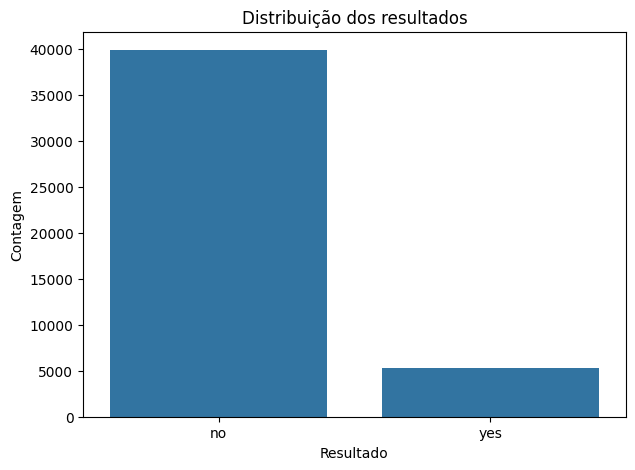

In [8]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='result', data=df)
plt.title('Distribuição dos resultados')
plt.xlabel('Resultado')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras mostra um desbalanceamento entre as categorias. Enquanto cerca de 5 mil (12%) são registros de casos bem-sucedidos, 40 mil (88%) são registros de casos mal-sucedidos. Na etapa de pré-processamento iremos verificar a melhor forma de diminuir essa diferença.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [9]:
# estatísticas descritivas básicas do dataset
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Análise inicial:**
- **age**: os valores de idade parecem estar dentro de uma distribuição esperada, com valores mínimos e máximos dentro do esperado.
- **balance**: o balanço médio anual apresenta uma amplitude de valores (min: -8019 e max: 102127). Embora, sejam valores significativos, não necessariamente são outliers, indicando que o banco buscou abordar diferentes tipos de clientes.
- **day_of_week**: embora a descrição dê a entender que sejam dias da semana (ou seja, entre 1 e 7), as variáveis demonstram que são dias do mês, entre 1 e 31.
- **duration**: embora represente o tempo em segundos, o valor máximo ser de 4918 (81 minutos) provavelmente indica um outiler.
- **campaign**: não temos a informação de quanto tempo durou a campanha, mas pelas informações descritivas (média, desvio padrão e mediana), o valor máximo de 63 ligações pode representar um outlier.
- **pdays**: dias de folga, desde o último contato. O valor -1 indica que não que o cliente não foi contatado anteriormente. Um ponto de atenção é que pelo menos 75% do conjunto de dados é composto de -1, indicando que a grande maioria dos contatos foram feitos pela primeira vez. Além disso, o valor máximo de 871 é um provável outlier, pois é valor muito discrepante dos demais valores da distribuição.
- **previous**: número de contatos realizados antes dessa campanha. As informações apresentadas demonstram que pelo menos 75% do conjunto de clientes nunca foi contatado em campanhas anteriores. Desse modo, o valor máximo de 275 também pode representar um outlier.

## *Análise das variáveis*
Além das medidas descritivas, é importante analisar a **distribuição dos dados**. Esta análise é crucial, pois permite um melhor entendimento dos dados, revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers).

Dentre os principais gráficos para realizar esta análise destacam-se o **histograma**, **gráfico de barras** e o **boxplot**. O *histograma* é utilizado para avaliar variáveis contínuas, representando a distribuição dos dados, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

O *gráfico de barras*, por sua vez, permite contar a quantidade de observações por variável categórica e realizar análises como comparação, contagem, rankeamento.

Já o *boxplot* é amplamente utilizado quando queremos comparar diferentes distribuições. Ele permite analisar quartis, medianas e outliers por variável.

A seguir traremos a análise de cada uma das variáveis do dataset.

### age (idade)

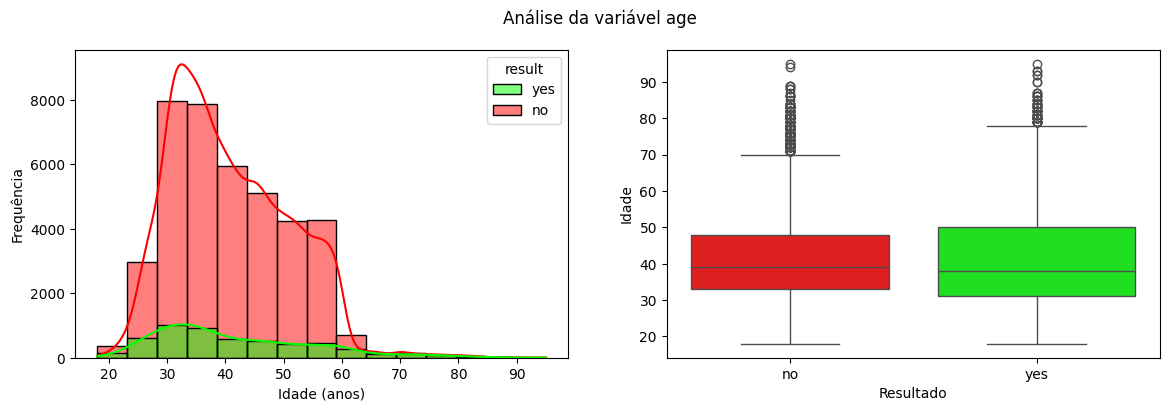

In [19]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável age')

sns.histplot(data=df, kde=True, binwidth=5, x='age', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Idade (anos)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='age', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Idade')
plt.show()

Como observado na figura, podemos dizer que há uma distribuilção assimétrica a esquerda.

A grande diferença entre casos negativos e casos positivos, acaba dificultando uma análise clara das curvas de comportamento. Após a etapa de pré-processamento, poderá ser observado melhor a influência dessa variável com relação ao resultado da campanha.

No entanto, a priori, podemos dizer que não há uma distinção tão evidente no formato da curva dos que negaram o contrato, para os que aceitaram o contrato. Além disso, há poucos indícios de outliers, pois os valores apresentados estão dentro dos limites consideráveis de tempo de vida humana.

### job (ocupação)

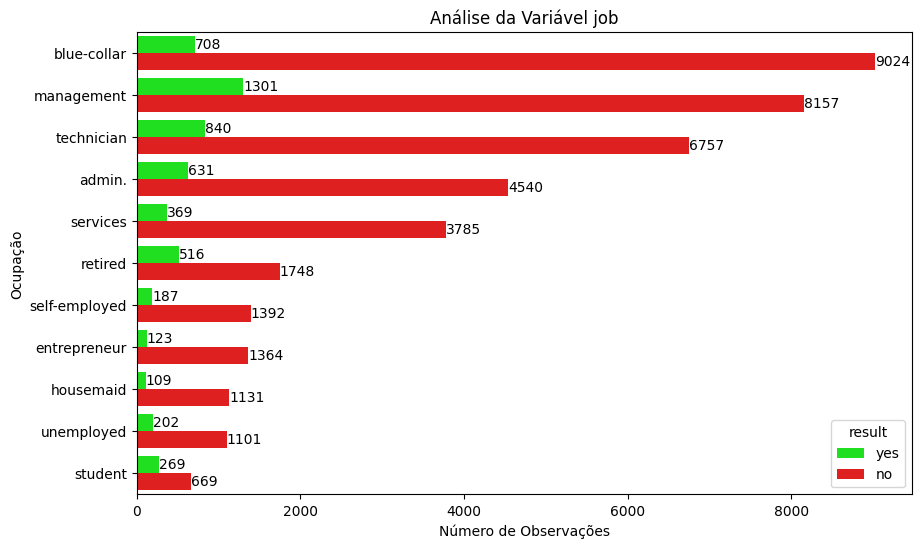

In [66]:
plt.figure(figsize=(10,6))
df_group = df.groupby(['job', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, x="size", y='job', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável job")
plt.xlabel('Número de Observações')
plt.ylabel('Ocupação')
plt.show()

### marital (estado civil)

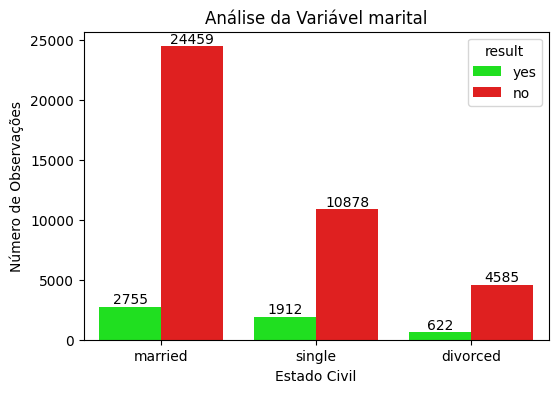

In [73]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['marital', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='marital', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável marital")
plt.xlabel('Estado Civil')
plt.ylabel('Número de Observações')
plt.show()

### education (nível de escolaridade)

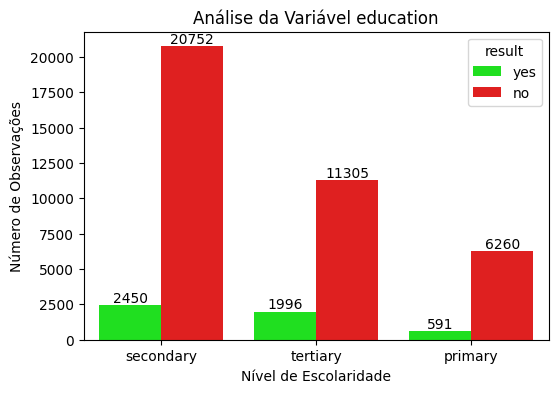

In [74]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['education', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='education', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável education")
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Número de Observações')
plt.show()

### default (incumprimento financeiro no passado?)

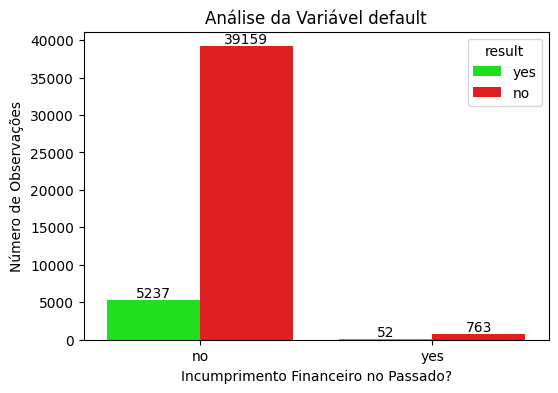

In [76]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['default', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='default', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável default")
plt.xlabel('Incumprimento Financeiro no Passado?')
plt.ylabel('Número de Observações')
plt.show()

### balance (saldo médio anual)

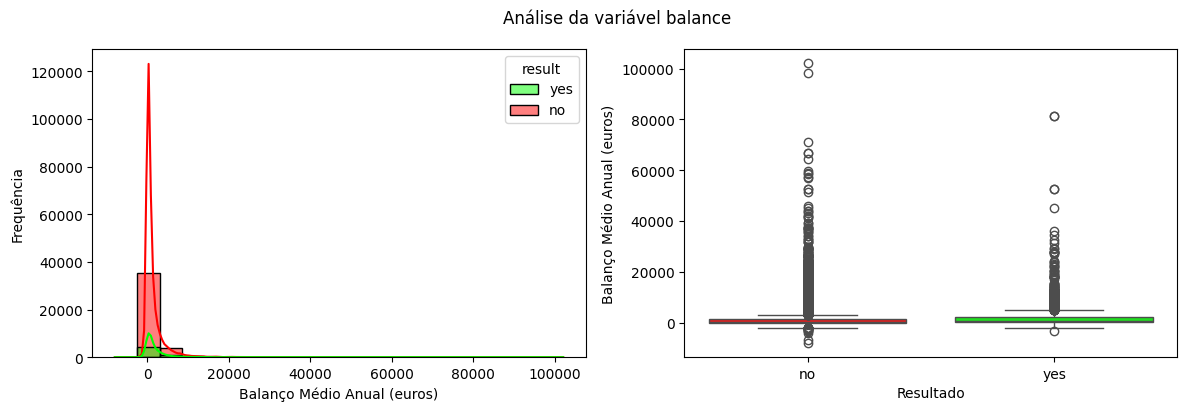

In [72]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável balance')

sns.histplot(data=df, kde=True, bins=20, x='balance', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Balanço Médio Anual (euros)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='balance', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Balanço Médio Anual (euros)')
plt.show()

### housing (possui empréstimo imobiário?)

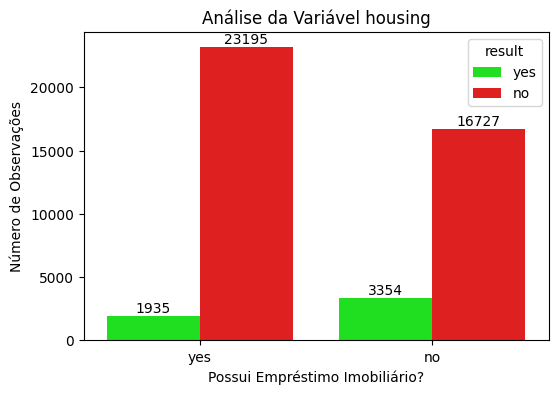

In [78]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['housing', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='housing', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável housing")
plt.xlabel('Possui Empréstimo Imobiliário?')
plt.ylabel('Número de Observações')
plt.show()

### loan (possui empréstimo pessoal?)

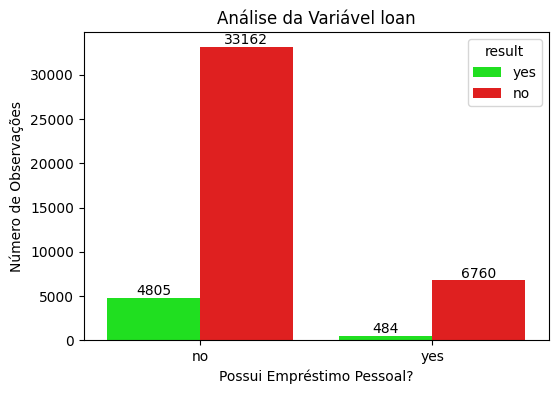

In [79]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['loan', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='loan', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável loan")
plt.xlabel('Possui Empréstimo Pessoal?')
plt.ylabel('Número de Observações')
plt.show()

### contact (tipo de contato)

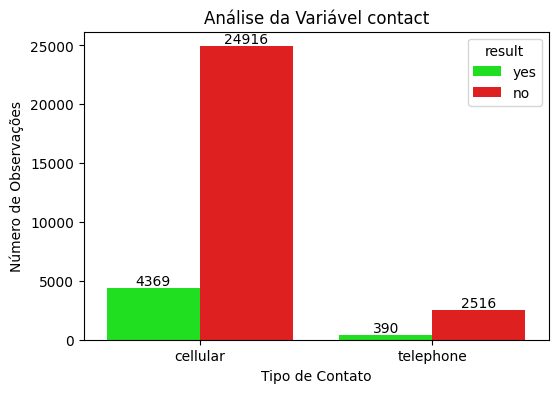

In [81]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['contact', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='contact', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável contact")
plt.xlabel('Tipo de Contato')
plt.ylabel('Número de Observações')
plt.show()

### day_of_week (último dia de contato)

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, kde=True, binwidth=1, x='day_of_week', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Distribuição do Dia da Semana")
plt.xlabel('Dia da Semana')
plt.ylabel('Frequência')
plt.show()

A distribuição apresentada está mais próxima de uma distribuição multimodal.

Do mesmo modo que a variável anterior, a diferença no número de registros de cada classe, acaba dificultando uma análise mais acertiva.

Outro ponto importante a se observar é que o nome da variável não condiz com os valores da distribuição. O nome da variável dá a entender que o valor representa o dia da semana, que deveria variar entre segunda a domingo. Mas os valores apresentados, na verdade, se referem ao dia do mês em que foi feito o contato. Isso seria interessante, se buscarmos entender o comportamento ao longo do mês, mas se a análise for feita por dia da semana, é necessário agrupar esses valores por dia da semana.

### month (mês do último contato)

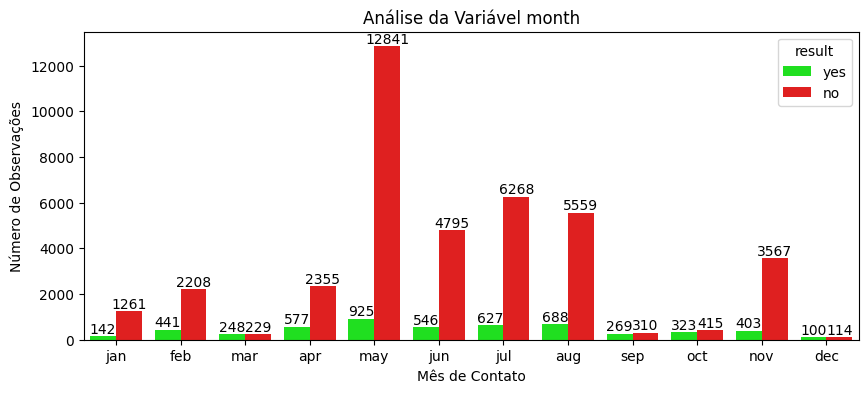

In [87]:
plt.figure(figsize=(10,4))
df_group = df.groupby(['month', 'result'], as_index=False).size()
order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
ax = sns.barplot(df_group, y="size", x='month', hue="result", order=order, palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável month")
plt.xlabel('Mês de Contato')
plt.ylabel('Número de Observações')
plt.show()

 ### duration (duração da ligação)

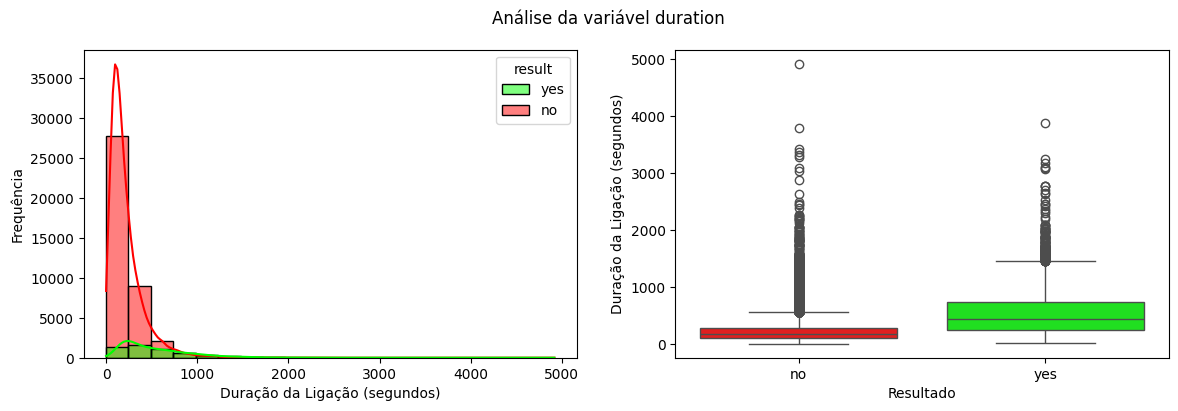

In [89]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável duration')

sns.histplot(data=df, kde=True, bins=20, x='duration', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Duração da Ligação (segundos)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='duration', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Duração da Ligação (segundos)')
plt.show()

### campaign (número de contatos realizados na campanha)

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, kde=True, binwidth=2, x='campaign', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Distribuição do Número de Contatos Realizados")
plt.xlabel('Número de Contatos')
plt.ylabel('Frequência')
plt.show()

A variável foi divida em faixa de valores para facilitar a visualização. A largura do bin definida foi de 2. Observa-se a presença de outliers, pois uma quantidade ínfima de clientes chegou a ser contactado 63 vezes, sendo que o normal foi realizar o contato entre 2 e 10 vezes.

A presença desses outliers e o desbalanceamento prejudicaram uma melhor visualização da distribuição.

### pdays (número de dias desde o último contato)

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, kde=True, binwidth=10, x='pdays', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Distribuição dos Dias do Último Contato")
plt.xlabel('Dias do Último Contato')
plt.ylabel('Frequência')
plt.show()

A variável foi divida em faixa de valores para facilitar a visualização. A largura do bin definida foi de 10. Observa-se uma concentração expressiva de valores próximo ao valor 0, inclusive, menores que 0. Isso indica que a maioria dos clientes não foi contactado antes, ou foram contactados poucas vezes.

Além disso, observa-se a presença de outliers, pois uma quantidade ínfima de clientes só foram contactados novamente muito tempo depois, chegando até a 800 dias depois, sendo que o normal tentar um novo contato, no máximo 10 dias depois do primeiro, ou serem novos contatos.

A presença desses outliers e o desbalanceamento prejudicaram uma melhor visualização da distribuição.

### previous (número de contatos realizados antes desta campanha)

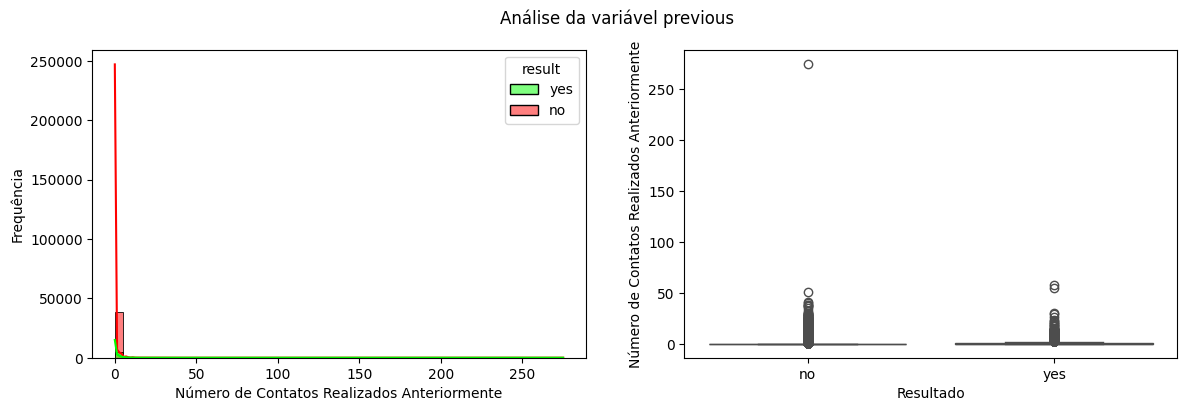

In [98]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável previous')

sns.histplot(data=df, kde=True, binwidth=5, x='previous', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Número de Contatos Realizados Anteriormente')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='previous', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Número de Contatos Realizados Anteriormente')
plt.show()

In [104]:
df.groupby(['previous', 'result'], as_index=False).size().iloc[0:10]

,previous,result,size
0,0,no,33570
1,0,yes,3384
2,1,no,2189
3,1,yes,583
4,2,no,1650
5,2,yes,456
6,3,no,848
7,3,yes,294
8,4,no,543
9,4,yes,171


### poutcome (resultado da campanha anterior)

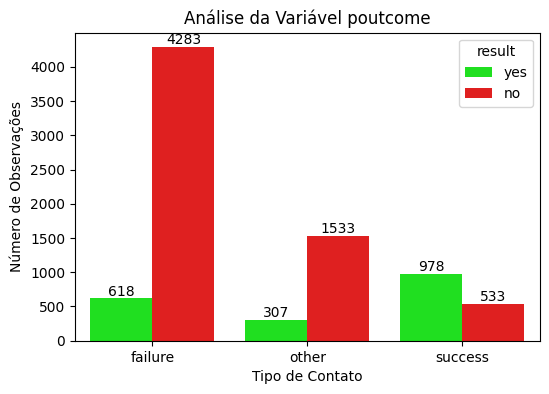

In [105]:
plt.figure(figsize=(6,4))
df_group = df.groupby(['poutcome', 'result'], as_index=False).size()
df_group = df_group.sort_values(by="size", ascending=False)
ax = sns.barplot(df_group, y="size", x='poutcome', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
ax.bar_label(ax.containers[0], fontsize=10);
ax.bar_label(ax.containers[1], fontsize=10);
plt.title("Análise da Variável poutcome")
plt.xlabel('Tipo de Contato')
plt.ylabel('Número de Observações')
plt.show()

Analisando o resultado desse gráfico podemos perceber duas coisas relevantes:
- Dentre as pessoas que aderiram à campanha anterior (sucess), a quantidade pessoas que também aderiram a campanha atual foi maior do que os que não aderiram;
- Dentre as pessoas que recusaram a campanha anterior, a grande maioria também recusou a campanha atual.

Isso mostra que o produto foi bem apreciado por quem experimentou, mas dificilmente os clientes são convencidos de que é um bom produto.

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


### day_of_week

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='result', y='day_of_week', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Boxplot da Variável Dia da Semana")
plt.xlabel('Resultado')
plt.ylabel('Dia da Semana')
plt.show()

### campaign

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='result', y='campaign', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Boxplot da Variável Número de Contatos Realizados")
plt.xlabel('Resultado')
plt.ylabel('Número de Contatos Realizados')
plt.show()

### pdays

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='result', y='pdays', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
plt.title("Boxplot da Variável Dias do Último Contato")
plt.xlabel('Resultado')
plt.ylabel('Dias do Último Contato')
plt.show()

In [ ]:
variaveis_numericas = [
    'age',
    'balance',
    'day_of_week',
    'duration',
    'campaign',
    'pdays',
    'previous'
]
fig, ax = plt.subplots(3,3, figsize = (17, 10))
fig.suptitle('Boxplot das numéricas por classe')
l, c = 0, 0
for x in variaveis_numericas:
  sns.boxplot(x='result', y=x, data=df, ax=ax[l,c], hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'])
  ax[l,c].set_xlabel('Resultado')
  ax[l,c].set_ylabel(x)
  c += 1
  if c == 3:
    c = 0
    l += 1

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df[variaveis_numericas].corr()

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Bank Marketing Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.